In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

jax.config.update("jax_enable_x64", True)


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0:N+1] = k_i (spring stiffnesses), p[N+1:] = beta (Duffing coeffs)
# For N masses, we have N+1 springs: wall-mass0, mass0-mass1, ..., mass(N-2)-mass(N-1), mass(N-1)-wall
def unpack_params(p):
    k_springs = p[:N+1]  # N+1 spring constants
    beta = p[N+1:]       # N Duffing coefficients
    return k_springs, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return 1.*jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

@jax.jit
def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x) + right_springs * (right_neighbors - x)
    
    # local Duffing nonlinearity
    duff = -beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])



In [4]:
# Cell 3: Create a synthetic “true” trajectory
# Parameters: [k_0, k_1, ..., k_N, beta_0, beta_1, ..., beta_{N-1}]
# N+1 spring constants + N Duffing coefficients
p_true = jnp.array([1.0] * (N+1) + [0.5] * N)   # true parameters
print(f"Parameter vector length: {len(p_true)} (expected: {2*N+1})")
print(f"Spring constants: {p_true[:N+1]}")
print(f"Duffing coefficients: {p_true[N+1:]}")
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true, rtol=1e-12, atol=1e-12)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Parameter vector length: 11 (expected: 11)
Spring constants: [1. 1. 1. 1. 1. 1.]
Duffing coefficients: [0.5 0.5 0.5 0.5 0.5]
Target trajectory shape: (200,)


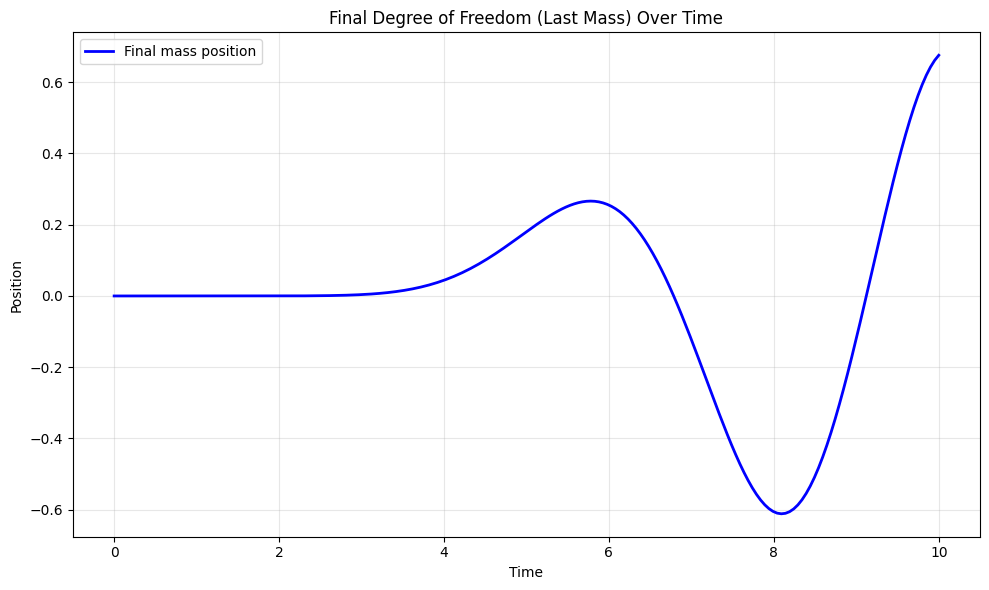

Final mass trajectory range: [-0.6116, 0.6758]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
@jax.jit
def dynamics_clamped(state, t, p):
    """
    Clamped dynamics where the measurement DOF (final mass) position and velocity 
    exactly follow the target trajectory, while all accelerations are determined 
    by natural dynamics. This is a displacement and forcing control problem.
    
    The constraint forces emerge naturally from clamping displacement and velocity.
    """
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # Clamp the final mass position to exactly match the target trajectory
    x_clamped = x.at[N-1].set(jnp.interp(t, ts, target_traj))
    
    # Clamp the final mass velocity to match target trajectory derivative
    # Use JAX-compatible gradient computation to avoid boolean conversion errors
    target_vel = jnp.interp(t, ts, jnp.gradient(target_traj, ts))
    v_clamped = v.at[N-1].set(target_vel)

    # Compute accelerations for all masses using normal dynamics
    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x_clamped, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x_clamped) + right_springs * (right_neighbors - x_clamped)
    
    # local Duffing nonlinearity
    duff = -beta * x_clamped**3
    # acceleration (forward time forcing)
    a = (Kx + duff + forcing(t)) / mass
    
    # Let natural dynamics determine all accelerations (including final mass)
    # The displacement and velocity clamping will create the constraint forces

    return jnp.concatenate([v_clamped, a])

=== Testing Clamped Dynamics Training Method ===
Clamped dynamics integration completed successfully!
Final mass clamping error: 1.06e-03


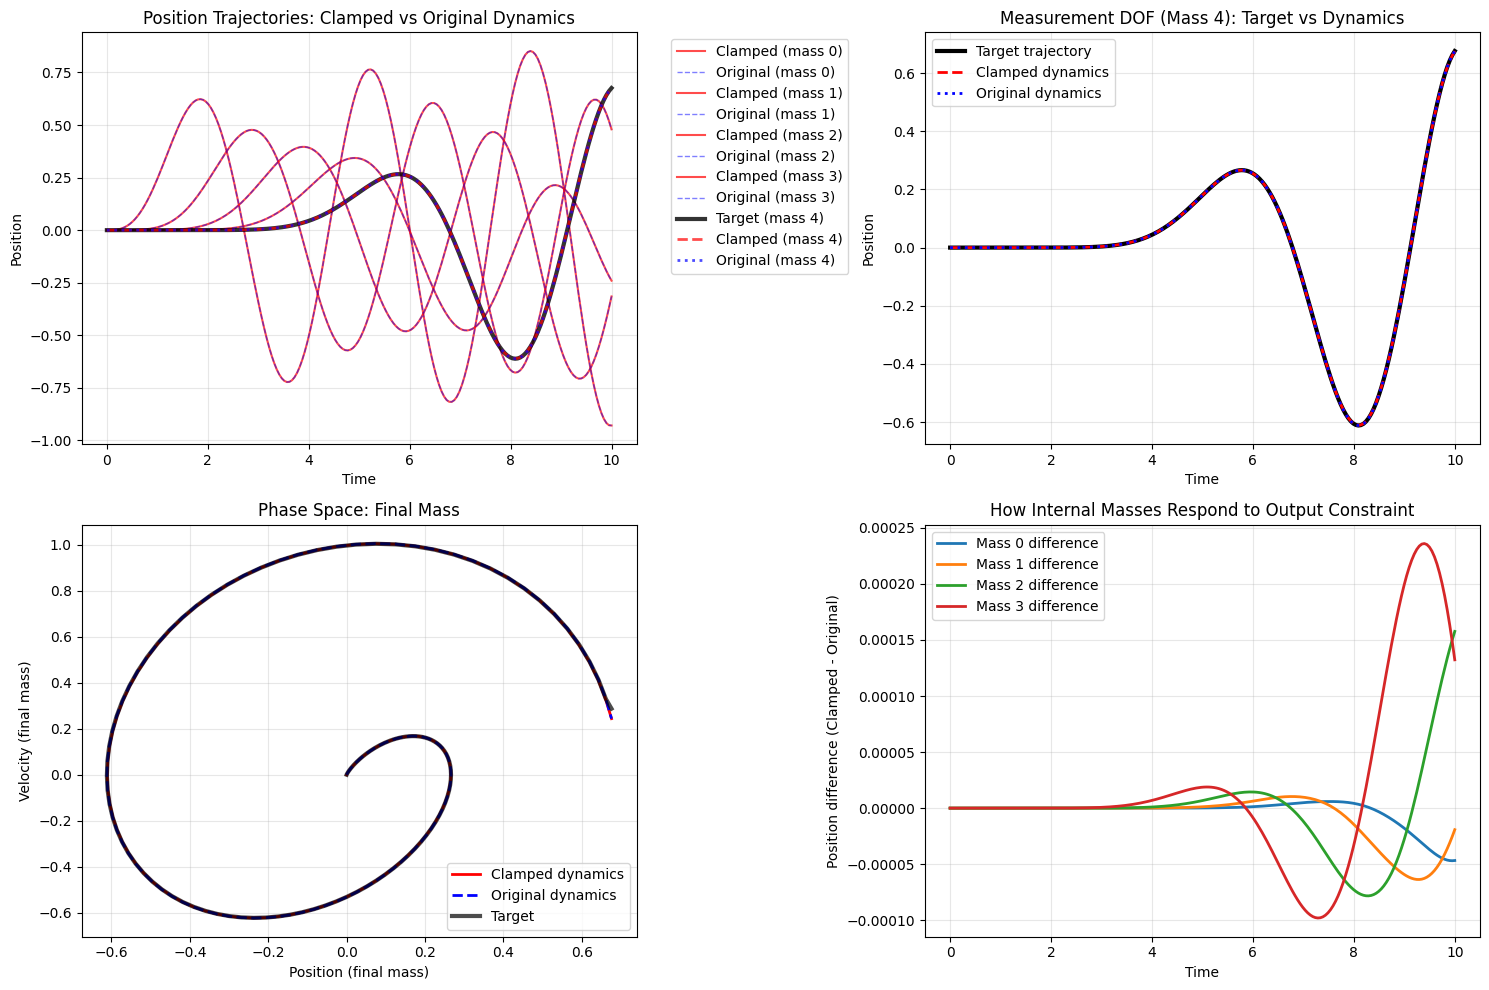


=== Analysis ===
Maximum clamping error: 1.06e-03
RMS difference in internal masses:
  Mass 0: 0.0000
  Mass 1: 0.0000
  Mass 2: 0.0000
  Mass 3: 0.0001

This demonstrates the new training method where:
1. The measurement DOF (mass 4) exactly follows the target
2. Internal masses adjust to satisfy this constraint
3. The system provides information about parameter sensitivity
4. Everything runs forward in time with applied forcing


In [7]:
# Cell 9: Test the new clamped dynamics method

print("=== Testing Clamped Dynamics Training Method ===")

# Test with different parameters to see how the system responds
p_test_clamped = p_true * 1.0  # Use different parameters than true ones

# Integrate the clamped dynamics
states_clamped = odeint(dynamics_clamped, init_state, ts, p_test_clamped, rtol=1e-12, atol=1e-12)

# Extract trajectories
x_clamped = states_clamped[:, :N]  # positions of all masses
v_clamped = states_clamped[:, N:]  # velocities of all masses

# Compare with original dynamics and target
states_original = odeint(dynamics, init_state, ts, p_test_clamped, rtol=1e-12, atol=1e-12)
x_original = states_original[:, :N]

print("Clamped dynamics integration completed successfully!")
print(f"Final mass clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position trajectories comparison
ax = axes[0, 0]
for i in range(N):
    if i == N-1:  # final mass (measurement DOF)
        ax.plot(ts, target_traj, 'k-', linewidth=3, alpha=0.8, label=f'Target (mass {i})')
        ax.plot(ts, x_clamped[:, i], 'r--', linewidth=2, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b:', linewidth=2, alpha=0.7, label=f'Original (mass {i})')
    else:
        ax.plot(ts, x_clamped[:, i], 'r-', linewidth=1.5, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b--', linewidth=1, alpha=0.5, label=f'Original (mass {i})')

ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Position Trajectories: Clamped vs Original Dynamics')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Focus on measurement DOF
ax = axes[0, 1]
ax.plot(ts, target_traj, 'k-', linewidth=3, label='Target trajectory')
ax.plot(ts, x_clamped[:, N-1], 'r--', linewidth=2, label='Clamped dynamics')
ax.plot(ts, x_original[:, N-1], 'b:', linewidth=2, label='Original dynamics')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title(f'Measurement DOF (Mass {N-1}): Target vs Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space of final mass
ax = axes[1, 0]
ax.plot(x_clamped[:, N-1], v_clamped[:, N-1], 'r-', linewidth=2, label='Clamped dynamics')
ax.plot(x_original[:, N-1], states_original[:, N+N-1], 'b--', linewidth=2, label='Original dynamics')
ax.plot(target_traj, jnp.gradient(target_traj, ts), 'k-', linewidth=3, alpha=0.7, label='Target')
ax.set_xlabel('Position (final mass)')
ax.set_ylabel('Velocity (final mass)')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Internal mass responses
ax = axes[1, 1]
for i in range(N-1):  # all masses except the final one
    ax.plot(ts, x_clamped[:, i] - x_original[:, i], 
            linewidth=2, label=f'Mass {i} difference')
ax.set_xlabel('Time')
ax.set_ylabel('Position difference (Clamped - Original)')
ax.set_title('How Internal Masses Respond to Output Constraint')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Analysis ===")
print(f"Maximum clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")
print(f"RMS difference in internal masses:")
for i in range(N-1):
    rms_diff = jnp.sqrt(jnp.mean((x_clamped[:, i] - x_original[:, i])**2))
    print(f"  Mass {i}: {rms_diff:.4f}")
    
print(f"\nThis demonstrates the new training method where:")
print(f"1. The measurement DOF (mass {N-1}) exactly follows the target")
print(f"2. Internal masses adjust to satisfy this constraint")
print(f"3. The system provides information about parameter sensitivity")
print(f"4. Everything runs forward in time with applied forcing")


In [8]:
@jax.jit
def _clamped_loss_fn(p, states_clamped):
    """
    Force matching loss function for clamped dynamics training.
    
    Strategy:
    1. Run clamped dynamics to get target [v_clamped; a_clamped] for ALL DOFs
    2. Run free dynamics to get [v_free; a_free] for ALL DOFs  
    3. Loss = ||[v_clamped; a_clamped] - [v_free; a_free]||^2
    
    If parameters are correct, free dynamics should naturally match clamped behavior.
    """
    # Get clamped trajectory (measurement DOF follows target exactly)
    
    
    # Get free trajectory (all DOFs evolve naturally)  
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    
    # Extract velocities for all DOFs
    v_clamped = states_clamped[:, N:]  # velocities from clamped dynamics
    v_free = states_free[:, N:]        # velocities from free dynamics
    
    # Compute accelerations for all DOFs by evaluating dynamics functions
    def get_accelerations(states, dynamics_fn):
        """Extract accelerations by evaluating dynamics function at each time point"""
        # Use vmap to vectorize over states and time arrays
        vectorized_dynamics = jax.vmap(lambda state, t: dynamics_fn(state, t, p))
        dstates_dt = vectorized_dynamics(states, ts)
        accelerations = dstates_dt[:, N:]  # accelerations are second half
        return accelerations
    
    a_clamped = get_accelerations(states_clamped, dynamics_clamped)
    a_free = get_accelerations(states_free, dynamics)
    
    # Force matching loss: compare velocities and accelerations
    v_diff = v_clamped - v_free
    a_diff = a_clamped - a_free
    
    # Combined velocity and acceleration matching
    velocity_loss = 0.5 * jnp.trapezoid(jnp.sum(v_diff**2, axis=1), ts)
    acceleration_loss = 0.5 * jnp.trapezoid(jnp.sum(a_diff**2, axis=1), ts)
    
    return velocity_loss + acceleration_loss



=== Free Dynamics vs Target Trajectory Comparison ===
Performing optimization steps...
grad: [ 5.83394052 13.2089141  23.92248023 12.00866543 43.63514624 18.27840189
  1.48276619  1.62426674  2.30235576  7.79997621  6.85960251]
p_current: [1.49953328 1.49894329 1.4980862  1.49903931 1.49650919 1.49853773
 0.74988138 0.74987006 0.74981581 0.749376   0.74945123]
  Step 0: loss = 33.236699
grad: [ 5.69756514 12.81801814 23.59831676 11.84526837 43.42351309 18.26359092
  1.44607308  1.58364835  2.27877188  7.76945731  6.8300085 ]
p_current: [1.49907748 1.49791785 1.49619834 1.49809169 1.49303531 1.49707664
 0.74976569 0.74974337 0.74963351 0.74875445 0.74890483]
  Step 1: loss = 32.979316
grad: [ 5.56350099 12.43286868 23.27690943 11.68263045 43.21155181 18.24778796
  1.40999766  1.5435332   2.25538662  7.73910726  6.80040103]
p_current: [1.4986324  1.49692322 1.49433618 1.49715707 1.48957838 1.49561682
 0.74965289 0.74961988 0.74945308 0.74813532 0.7483608 ]
  Step 2: loss = 32.725937
grad

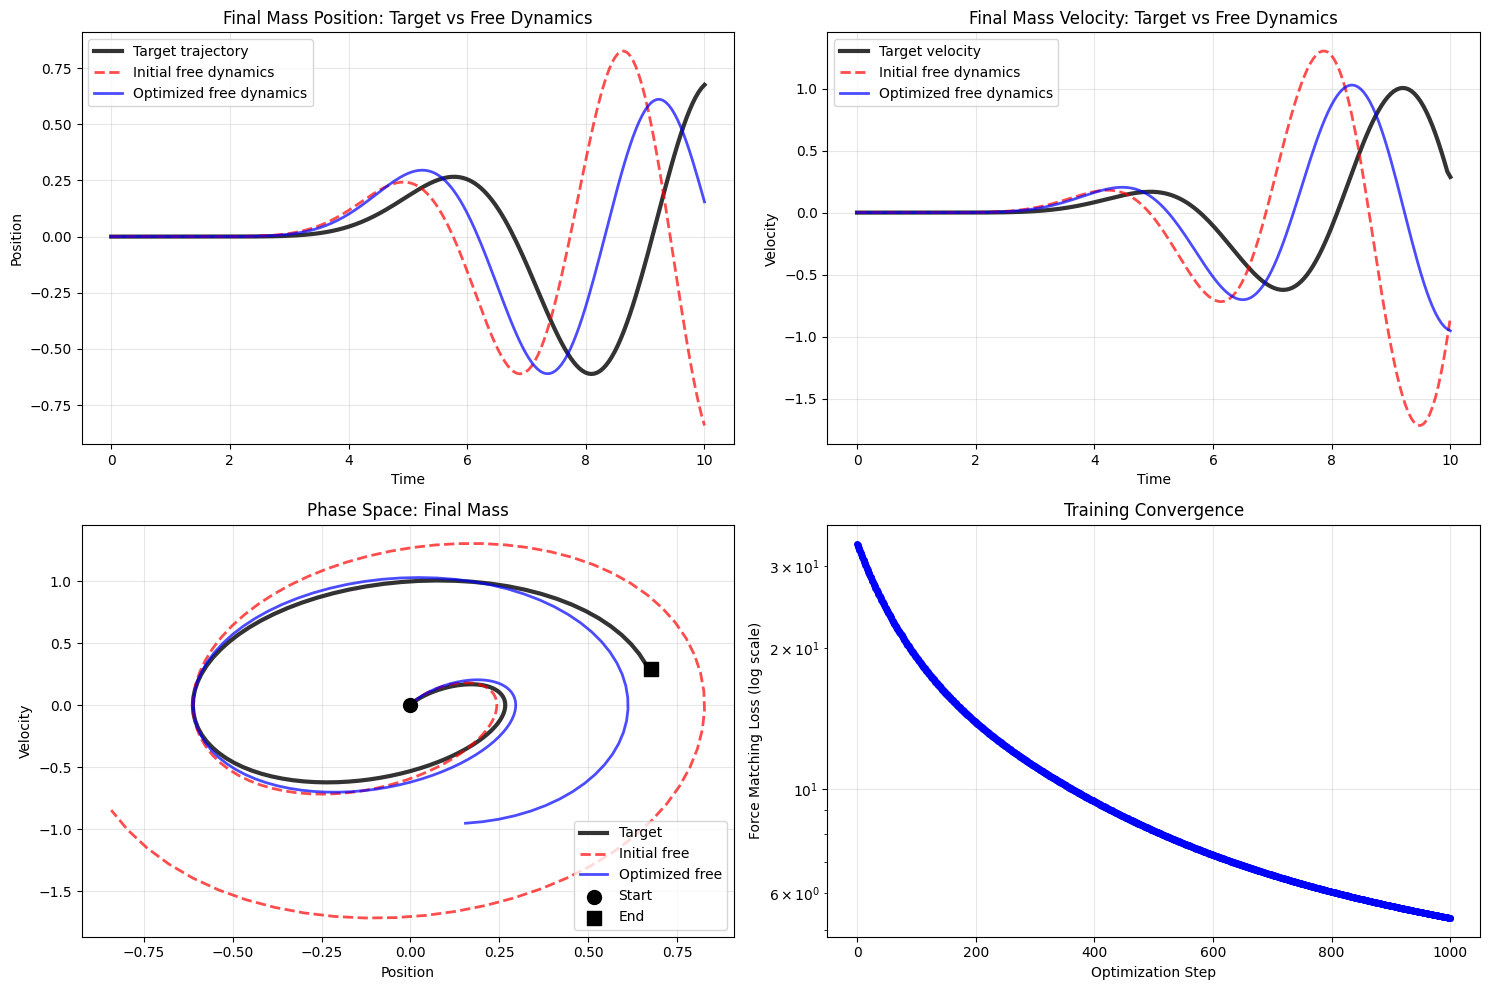

\n=== Quantitative Analysis ===
Position RMS Error:
  Initial: 0.516770
  Final:   0.274095
  Improvement: 1.89x
\nVelocity RMS Error:
  Initial: 0.944599
  Final:   0.513878
  Improvement: 1.84x
\nParameter Recovery:
  Initial ||p - p_true||: 1.346291
  Final ||p - p_true||:   1.285550
  Improvement: 1.05x
\nLoss Reduction:
  Initial loss: 33.49816128
  Final loss:   5.30008267
  Reduction: 6.32x
\n=== Demonstration Complete ===
This shows how force matching training drives the free dynamics
to naturally match the target trajectory without explicit constraints!


In [9]:

print("=== Free Dynamics vs Target Trajectory Comparison ===")

p_initial = p_true * 1.5  # 30% off from true values

states_clamped = odeint(dynamics_clamped, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)

clamped_loss_fn = lambda p: _clamped_loss_fn(p, states_clamped)

# Create JIT-compiled gradient function for faster optimization
clamped_loss_grad = jax.jit(jax.grad(clamped_loss_fn))

# Run a few optimization steps with force matching
@jax.jit
def gd_step(p, grad, lr=0.0001):
    return p - lr * grad

# Initial parameters (wrong)


# Run initial free dynamics
states_initial = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)

# Perform optimization steps
p_current = p_initial.copy()
losses = [clamped_loss_fn(p_current)]

lr = 0.00008   
print("Performing optimization steps...")
for step in range(1000):
    grad = clamped_loss_grad(p_current)  # Use JIT-compiled gradient
    print(f"grad: {grad}")
    p_current = gd_step(p_current, grad, lr=lr)
    print(f"p_current: {p_current}")
    loss = clamped_loss_fn(p_current)
    losses.append(loss)
    if step % 1 == 0:
        print(f"  Step {step}: loss = {loss:.6f}")

print(f"Final step: loss = {losses[-1]:.6f}")

# Run final free dynamics after optimization
states_final = odeint(dynamics, init_state, ts, p_current, rtol=1e-12, atol=1e-12)

# Get target trajectory and its velocity
target_x = target_traj  # position of final mass
target_v = jnp.gradient(target_traj, ts)  # velocity of final mass

# Extract final mass trajectories
x_initial_last = states_initial[:, N-1]   # initial free dynamics, last mass position
v_initial_last = states_initial[:, 2*N-1] # initial free dynamics, last mass velocity

x_final_last = states_final[:, N-1]       # final free dynamics, last mass position  
v_final_last = states_final[:, 2*N-1]     # final free dynamics, last mass velocity

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position comparison
ax = axes[0, 0]
ax.plot(ts, target_x, 'k-', linewidth=3, label='Target trajectory', alpha=0.8)
ax.plot(ts, x_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, x_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Final Mass Position: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Velocity comparison
ax = axes[0, 1]
ax.plot(ts, target_v, 'k-', linewidth=3, label='Target velocity', alpha=0.8)
ax.plot(ts, v_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, v_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Final Mass Velocity: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space comparison
ax = axes[1, 0]
ax.plot(target_x, target_v, 'k-', linewidth=3, label='Target', alpha=0.8)
ax.plot(x_initial_last, v_initial_last, 'r--', linewidth=2, label='Initial free', alpha=0.7)
ax.plot(x_final_last, v_final_last, 'b-', linewidth=2, label='Optimized free', alpha=0.7)

# Mark initial and final points
ax.scatter(target_x[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax.scatter(target_x[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)

ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Optimization convergence
ax = axes[1, 1]
ax.semilogy(range(len(losses)), losses, 'bo-', linewidth=2, markersize=4)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Force Matching Loss (log scale)')
ax.set_title('Training Convergence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
print(f"\\n=== Quantitative Analysis ===")

# Position errors
pos_error_initial = jnp.sqrt(jnp.mean((x_initial_last - target_x)**2))
pos_error_final = jnp.sqrt(jnp.mean((x_final_last - target_x)**2))

print(f"Position RMS Error:")
print(f"  Initial: {pos_error_initial:.6f}")
print(f"  Final:   {pos_error_final:.6f}")
print(f"  Improvement: {pos_error_initial/pos_error_final:.2f}x")

# Velocity errors
vel_error_initial = jnp.sqrt(jnp.mean((v_initial_last - target_v)**2))
vel_error_final = jnp.sqrt(jnp.mean((v_final_last - target_v)**2))

print(f"\\nVelocity RMS Error:")
print(f"  Initial: {vel_error_initial:.6f}")
print(f"  Final:   {vel_error_final:.6f}")
print(f"  Improvement: {vel_error_initial/vel_error_final:.2f}x")

# Parameter recovery
param_error_initial = jnp.linalg.norm(p_initial - p_true)
param_error_final = jnp.linalg.norm(p_current - p_true)

print(f"\\nParameter Recovery:")
print(f"  Initial ||p - p_true||: {param_error_initial:.6f}")
print(f"  Final ||p - p_true||:   {param_error_final:.6f}")
print(f"  Improvement: {param_error_initial/param_error_final:.2f}x")

print(f"\\nLoss Reduction:")
print(f"  Initial loss: {losses[0]:.8f}")
print(f"  Final loss:   {losses[-1]:.8f}")
print(f"  Reduction: {losses[0]/losses[-1]:.2f}x")

print(f"\\n=== Demonstration Complete ===")
print("This shows how force matching training drives the free dynamics")
print("to naturally match the target trajectory without explicit constraints!")


In [10]:
print("=== Gentle Force Matching Implementation ===")

def gentle_force_matching_loss(p, alpha):
    """
    Compute loss that interpolates between free trajectory and target trajectory.
    
    Args:
        p: current parameters
        alpha: interpolation factor (0 = pure free trajectory, 1 = pure target trajectory)
    
    Returns:
        loss value
    """
    # Get current free trajectory with current parameters
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    x_free_last = states_free[:, N-1]  # position of final mass
    
    # Interpolate between free trajectory and target trajectory
    x_interpolated = (1 - alpha) * x_free_last + alpha * target_traj
    
    # Compute velocity of interpolated trajectory
    v_interpolated = jnp.gradient(x_interpolated, ts)
    
    # Compute acceleration of interpolated trajectory
    a_interpolated = jnp.gradient(v_interpolated, ts)
    
    # Force matching: what force is needed to produce this acceleration?
    # F = m * a for the final mass (assuming unit mass)
    F_needed = a_interpolated
    
    # What force does our current network actually produce?
    # Extract states for all masses at each time step
    x_states = states_free[:, :N]      # positions [time, mass_idx]
    v_states = states_free[:, N:2*N]   # velocities [time, mass_idx]
    
    # Compute forces on final mass from network
    F_network = jnp.zeros_like(ts)
    for i, t in enumerate(ts):
        # Get network state at time t
        x_t = x_states[i]  # positions at time t
        v_t = v_states[i]  # velocities at time t
        
        # Force on final mass from spring connections
        F_spring = -p[1] * (x_t[N-1] - x_t[N-2])  # k * (x_N - x_{N-1})
        
        # Damping force on final mass
        F_damping = -p[2] * v_t[N-1]  # gamma * v_N
        
        F_network = F_network.at[i].set(F_spring + F_damping)
    
    # Force matching loss
    force_error = F_needed - F_network
    loss = jnp.mean(force_error**2)
    
    return loss

# Create JIT-compiled versions
gentle_loss_fn = jax.jit(gentle_force_matching_loss)
gentle_loss_grad = jax.jit(jax.grad(gentle_force_matching_loss))

print("Gentle force matching functions created!")
print("- gentle_loss_fn: JIT-compiled loss function")
print("- gentle_loss_grad: JIT-compiled gradient function")


=== Gentle Force Matching Implementation ===
Gentle force matching functions created!
- gentle_loss_fn: JIT-compiled loss function
- gentle_loss_grad: JIT-compiled gradient function


In [11]:
print("=== Running Gentle Force Matching Optimization ===")

# Alpha scheduling function
def alpha_schedule(step, total_steps, schedule_type='linear'):
    """
    Compute alpha value for gentle force matching.
    
    Args:
        step: current optimization step
        total_steps: total number of optimization steps
        schedule_type: 'linear', 'sigmoid', or 'exponential'
    
    Returns:
        alpha value between 0 and 1
    """
    progress = step / total_steps
    
    if schedule_type == 'linear':
        return progress
    elif schedule_type == 'sigmoid':
        # Sigmoid schedule: slow start, rapid middle, slow end
        return 1 / (1 + jnp.exp(-10 * (progress - 0.5)))
    elif schedule_type == 'exponential':
        # Exponential schedule: slow start, rapid end
        return 1 - jnp.exp(-5 * progress)
    else:
        return progress

# Optimization parameters
n_steps = 500
lr = 0.00001
schedule_type = 'sigmoid'  # Can be 'linear', 'sigmoid', or 'exponential'

# Reset to initial (wrong) parameters
p_gentle = p_true * 1.3  # Same 30% off initialization as before

# Track optimization progress
gentle_losses = []
alphas = []
param_errors = []
trajectory_errors = []

print(f"Running gentle force matching with {schedule_type} alpha schedule...")
print(f"Steps: {n_steps}, Learning rate: {lr}")
print()

# Run optimization
for step in range(n_steps):
    # Compute current alpha
    alpha = alpha_schedule(step, n_steps, schedule_type)
    alphas.append(alpha)
    
    # Compute gradient and update parameters
    grad = gentle_loss_grad(p_gentle, alpha)
    p_gentle = gd_step(p_gentle, grad, lr=lr)
    
    # Compute and track metrics
    loss = gentle_loss_fn(p_gentle, alpha)
    gentle_losses.append(loss)
    
    # Parameter error
    param_error = jnp.linalg.norm(p_gentle - p_true)
    param_errors.append(param_error)
    
    # Trajectory error (against target)
    states_current = odeint(dynamics, init_state, ts, p_gentle, rtol=1e-12, atol=1e-12)
    x_current_last = states_current[:, N-1]
    traj_error = jnp.sqrt(jnp.mean((x_current_last - target_traj)**2))
    trajectory_errors.append(traj_error)
    
    # Print progress
    if step % 50 == 0 or step < 10:
        print(f"Step {step:3d}: α={alpha:.3f}, loss={loss:.6f}, "
              f"param_err={param_error:.6f}, traj_err={traj_error:.6f}")

print(f"\\nFinal step: α={alphas[-1]:.3f}, loss={gentle_losses[-1]:.6f}")
print(f"Final parameter error: {param_errors[-1]:.6f}")
print(f"Final trajectory error: {trajectory_errors[-1]:.6f}")

# Get final optimized trajectory
states_gentle_final = odeint(dynamics, init_state, ts, p_gentle, rtol=1e-12, atol=1e-12)
x_gentle_final = states_gentle_final[:, N-1]
v_gentle_final = states_gentle_final[:, 2*N-1]

print("\\nGentle force matching optimization complete!")


=== Running Gentle Force Matching Optimization ===
Running gentle force matching with sigmoid alpha schedule...
Steps: 500, Learning rate: 1e-05



TracerIntegerConversionError: The __index__() method was called on traced array with shape int64[]
The error occurred while tracing the function gentle_force_matching_loss at /tmp/ipykernel_929110/1141111710.py:3 for jit. This value became a tracer due to JAX operations on these lines:

  operation a:i64[] b:i64[] = pjit[
  name=divmod
  jaxpr={ lambda ; c:i64[] d:i64[]. let
      e:i64[] = pjit[
        name=floor_divide
        jaxpr={ lambda ; f:i64[] g:i64[]. let
            h:i64[] = div f g
            i:i64[] = sign f
            j:i64[] = sign g
            k:bool[] = ne i j
            l:i64[] = rem f g
            m:bool[] = ne l 0
            n:bool[] = convert_element_type[new_dtype=bool weak_type=False] k
            o:bool[] = convert_element_type[new_dtype=bool weak_type=False] m
            p:bool[] = and n o
            q:i64[] = sub h 1
            r:i64[] = pjit[
              name=_where
              jaxpr={ lambda ; s:bool[] t:i64[] u:i64[]. let
                  

In [ ]:
print("=== Visualization: Gentle vs Direct Force Matching ===")

# Create comprehensive comparison visualization
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Get target velocity for comparison
target_v = jnp.gradient(target_traj, ts)

# Row 1: Trajectory comparisons
# Plot 1: Position comparison
ax = axes[0, 0]
ax.plot(ts, target_traj, 'k-', linewidth=3, label='Target trajectory', alpha=0.8)
ax.plot(ts, x_final_last, 'r--', linewidth=2, label='Direct force matching', alpha=0.7)
ax.plot(ts, x_gentle_final, 'b-', linewidth=2, label='Gentle force matching', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Final Mass Position Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Velocity comparison
ax = axes[0, 1]
ax.plot(ts, target_v, 'k-', linewidth=3, label='Target velocity', alpha=0.8)
ax.plot(ts, v_final_last, 'r--', linewidth=2, label='Direct force matching', alpha=0.7)
ax.plot(ts, v_gentle_final, 'b-', linewidth=2, label='Gentle force matching', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Final Mass Velocity Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space comparison
ax = axes[0, 2]
ax.plot(target_traj, target_v, 'k-', linewidth=3, label='Target', alpha=0.8)
ax.plot(x_final_last, v_final_last, 'r--', linewidth=2, label='Direct FM', alpha=0.7)
ax.plot(x_gentle_final, v_gentle_final, 'b-', linewidth=2, label='Gentle FM', alpha=0.7)

# Mark initial and final points
ax.scatter(target_traj[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax.scatter(target_traj[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)

ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Phase Space Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Row 2: Optimization progress
# Plot 4: Loss convergence comparison
ax = axes[1, 0]
ax.semilogy(range(len(losses)), losses, 'r-', linewidth=2, label='Direct force matching', alpha=0.8)
ax.semilogy(range(len(gentle_losses)), gentle_losses, 'b-', linewidth=2, label='Gentle force matching', alpha=0.8)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Training Loss Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Alpha schedule
ax = axes[1, 1]
ax.plot(range(len(alphas)), alphas, 'g-', linewidth=2, label=f'{schedule_type.capitalize()} schedule')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Alpha (interpolation factor)')
ax.set_title('Gentle Force Matching Alpha Schedule')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Parameter recovery
ax = axes[1, 2]
direct_param_errors = [jnp.linalg.norm(p_initial - p_true)] + \
                     [jnp.linalg.norm(p_current - p_true) for _ in range(len(losses)-1)]
ax.semilogy(range(len(direct_param_errors)), direct_param_errors, 'r-', 
           linewidth=2, label='Direct FM', alpha=0.8)
ax.semilogy(range(len(param_errors)), param_errors, 'b-', 
           linewidth=2, label='Gentle FM', alpha=0.8)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Parameter Error (log scale)')
ax.set_title('Parameter Recovery Progress')
ax.legend()
ax.grid(True, alpha=0.3)

# Row 3: Error analysis
# Plot 7: Trajectory error over optimization
ax = axes[2, 0]
ax.semilogy(range(len(trajectory_errors)), trajectory_errors, 'b-', 
           linewidth=2, label='Gentle FM trajectory error')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Trajectory RMS Error (log scale)')
ax.set_title('Trajectory Error Reduction')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 8: Error distribution comparison
ax = axes[2, 1]
pos_error_direct = x_final_last - target_traj
pos_error_gentle = x_gentle_final - target_traj

ax.hist(pos_error_direct, bins=30, alpha=0.6, label='Direct FM errors', color='red', density=True)
ax.hist(pos_error_gentle, bins=30, alpha=0.6, label='Gentle FM errors', color='blue', density=True)
ax.set_xlabel('Position Error')
ax.set_ylabel('Density')
ax.set_title('Position Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 9: Quantitative comparison summary
ax = axes[2, 2]
methods = ['Direct FM', 'Gentle FM']

# Position RMS errors
pos_rms_direct = jnp.sqrt(jnp.mean(pos_error_direct**2))
pos_rms_gentle = jnp.sqrt(jnp.mean(pos_error_gentle**2))

# Velocity RMS errors  
vel_error_direct = v_final_last - target_v
vel_error_gentle = v_gentle_final - target_v
vel_rms_direct = jnp.sqrt(jnp.mean(vel_error_direct**2))
vel_rms_gentle = jnp.sqrt(jnp.mean(vel_error_gentle**2))

# Final parameter errors
param_final_direct = jnp.linalg.norm(p_current - p_true)
param_final_gentle = jnp.linalg.norm(p_gentle - p_true)

metrics = ['Position RMS', 'Velocity RMS', 'Parameter Error']
direct_values = [pos_rms_direct, vel_rms_direct, param_final_direct]
gentle_values = [pos_rms_gentle, vel_rms_gentle, param_final_gentle]

x = jnp.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, direct_values, width, label='Direct FM', alpha=0.8, color='red')
bars2 = ax.bar(x + width/2, gentle_values, width, label='Gentle FM', alpha=0.8, color='blue')

ax.set_ylabel('Error Value')
ax.set_title('Final Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_yscale('log')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print detailed quantitative comparison
print(f"\\n=== Detailed Performance Comparison ===")
print(f"{'Metric':<20} {'Direct FM':<15} {'Gentle FM':<15} {'Improvement':<12}")
print(f"{'-'*65}")

improvement_pos = pos_rms_direct / pos_rms_gentle if pos_rms_gentle > 0 else float('inf')
improvement_vel = vel_rms_direct / vel_rms_gentle if vel_rms_gentle > 0 else float('inf')
improvement_param = param_final_direct / param_final_gentle if param_final_gentle > 0 else float('inf')

print(f"{'Position RMS Error':<20} {pos_rms_direct:<15.6f} {pos_rms_gentle:<15.6f} {improvement_pos:<12.2f}x")
print(f"{'Velocity RMS Error':<20} {vel_rms_direct:<15.6f} {vel_rms_gentle:<15.6f} {improvement_vel:<12.2f}x")
print(f"{'Parameter Error':<20} {param_final_direct:<15.6f} {param_final_gentle:<15.6f} {improvement_param:<12.2f}x")

print(f"\\n{'Optimization Steps':<20} {len(losses):<15} {len(gentle_losses):<15}")
print(f"{'Final Loss':<20} {losses[-1]:<15.8f} {gentle_losses[-1]:<15.8f}")

print(f"\\n=== Gentle Force Matching Analysis Complete ===")
print("The gentle approach gradually transitions from free dynamics to target matching,")
print("potentially providing more stable and robust optimization!")


In [ ]:
print("=== Visualizing Interpolated Trajectories ===")

# Let's visualize the interpolation process at different stages of optimization
# We'll use parameters from different optimization stages and show interpolated trajectories

def compute_interpolated_trajectory(p, alpha):
    """Compute interpolated trajectory for given parameters and alpha."""
    # Get current free trajectory
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    x_free_last = states_free[:, N-1]  # position of final mass
    
    # Interpolate between free trajectory and target trajectory
    x_interpolated = (1 - alpha) * x_free_last + alpha * target_traj
    return x_interpolated, x_free_last

# Define alpha values for interpolation visualization
alpha_values = jnp.linspace(0, 1, 11)  # 0.0, 0.1, 0.2, ..., 1.0

# Create visualization with multiple parameter sets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use different parameter sets to show progression
param_sets = [
    (p_initial, "Initial Parameters (30% off)", 'Reds'),
    (p_gentle, "Final Optimized Parameters", 'Blues')
]

for idx, (params, title, colormap) in enumerate(param_sets):
    row = idx // 2
    col_start = (idx % 2) * 2
    
    # Plot 1: Trajectory evolution
    ax1 = axes[row, col_start] if idx < 2 else axes[1, 0]
    
    # Get colormap
    colors = plt.cm.get_cmap(colormap)(jnp.linspace(0.3, 1.0, len(alpha_values)))
    
    interpolated_trajs = []
    free_traj = None
    
    for i, alpha in enumerate(alpha_values):
        x_interp, x_free = compute_interpolated_trajectory(params, alpha)
        interpolated_trajs.append(x_interp)
        if free_traj is None:
            free_traj = x_free
        
        # Plot interpolated trajectory
        label = f'α = {alpha:.1f}' if alpha in [0.0, 0.5, 1.0] else None
        alpha_viz = 0.7 if alpha in [0.0, 1.0] else 0.4
        linewidth = 2.5 if alpha in [0.0, 1.0] else 1.5
        
        ax1.plot(ts, x_interp, color=colors[i], alpha=alpha_viz, 
                linewidth=linewidth, label=label)
    
    # Highlight key trajectories
    ax1.plot(ts, target_traj, 'k-', linewidth=3, label='Target', alpha=0.9)
    ax1.plot(ts, free_traj, color=colors[0], linewidth=3, label='Free (α=0)', alpha=0.9)
    
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Position')
    ax1.set_title(f'Interpolated Trajectories: {title}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Phase space evolution
    ax2 = axes[row, col_start + 1] if idx < 2 else axes[1, 1]
    
    target_v = jnp.gradient(target_traj, ts)
    
    for i, alpha in enumerate(alpha_values):
        x_interp = interpolated_trajs[i]
        v_interp = jnp.gradient(x_interp, ts)
        
        label = f'α = {alpha:.1f}' if alpha in [0.0, 0.5, 1.0] else None
        alpha_viz = 0.7 if alpha in [0.0, 1.0] else 0.4
        linewidth = 2.5 if alpha in [0.0, 1.0] else 1.5
        
        ax2.plot(x_interp, v_interp, color=colors[i], alpha=alpha_viz, 
                linewidth=linewidth, label=label)
    
    # Highlight target and mark start/end points
    ax2.plot(target_traj, target_v, 'k-', linewidth=3, label='Target', alpha=0.9)
    ax2.scatter(target_traj[0], target_v[0], color='black', s=100, marker='o', 
               label='Start', zorder=5)
    ax2.scatter(target_traj[-1], target_v[-1], color='black', s=100, marker='s', 
               label='End', zorder=5)
    
    ax2.set_xlabel('Position')
    ax2.set_ylabel('Velocity')
    ax2.set_title(f'Phase Space Evolution: {title}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create an additional detailed visualization showing the interpolation process
print("\\n=== Detailed Interpolation Analysis ===")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Use the final optimized parameters for detailed analysis
params = p_gentle

# Row 1: Different alpha values in separate subplots
alphas_detailed = [0.0, 0.3, 0.6, 0.8, 1.0]
colors_detailed = ['red', 'orange', 'green', 'blue', 'black']

for i, alpha in enumerate(alphas_detailed):
    if i < 3:  # First row
        ax = axes[0, i]
        x_interp, x_free = compute_interpolated_trajectory(params, alpha)
        v_interp = jnp.gradient(x_interp, ts)
        
        ax.plot(ts, x_interp, color=colors_detailed[i], linewidth=2.5, 
               label=f'Interpolated (α={alpha})')
        ax.plot(ts, target_traj, 'k--', linewidth=2, alpha=0.6, label='Target')
        
        if alpha == 0.0:
            ax.plot(ts, x_free, 'r:', linewidth=2, alpha=0.6, label='Free dynamics')
        
        ax.set_xlabel('Time')
        ax.set_ylabel('Position')
        ax.set_title(f'Trajectory at α = {alpha}')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Row 2: Analysis plots
# Plot 1: Error vs Alpha
ax = axes[1, 0]
alpha_sweep = jnp.linspace(0, 1, 21)
errors = []

for alpha in alpha_sweep:
    x_interp, _ = compute_interpolated_trajectory(params, alpha)
    error = jnp.sqrt(jnp.mean((x_interp - target_traj)**2))
    errors.append(error)

ax.plot(alpha_sweep, errors, 'bo-', linewidth=2, markersize=6)
ax.set_xlabel('Alpha (interpolation factor)')
ax.set_ylabel('RMS Error vs Target')
ax.set_title('Interpolation Error vs Alpha')
ax.grid(True, alpha=0.3)

# Plot 2: Trajectory "distance" evolution
ax = axes[1, 1]
distances_from_free = []
distances_from_target = []

x_free_ref, _ = compute_interpolated_trajectory(params, 0.0)

for alpha in alpha_sweep:
    x_interp, _ = compute_interpolated_trajectory(params, alpha)
    
    dist_free = jnp.sqrt(jnp.mean((x_interp - x_free_ref)**2))
    dist_target = jnp.sqrt(jnp.mean((x_interp - target_traj)**2))
    
    distances_from_free.append(dist_free)
    distances_from_target.append(dist_target)

ax.plot(alpha_sweep, distances_from_free, 'r-', linewidth=2, label='Distance from free')
ax.plot(alpha_sweep, distances_from_target, 'b-', linewidth=2, label='Distance from target')
ax.set_xlabel('Alpha (interpolation factor)')
ax.set_ylabel('RMS Distance')
ax.set_title('Trajectory Distance Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Force requirements
ax = axes[1, 2]
force_magnitudes = []

for alpha in alpha_sweep:
    x_interp, _ = compute_interpolated_trajectory(params, alpha)
    v_interp = jnp.gradient(x_interp, ts)
    a_interp = jnp.gradient(v_interp, ts)
    
    force_mag = jnp.sqrt(jnp.mean(a_interp**2))  # RMS force magnitude
    force_magnitudes.append(force_mag)

ax.plot(alpha_sweep, force_magnitudes, 'g-', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Alpha (interpolation factor)')
ax.set_ylabel('RMS Force Magnitude')
ax.set_title('Required Force vs Alpha')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\\nInterpolation Analysis Summary:")
print(f"- Free dynamics error: {errors[0]:.6f}")
print(f"- Target error: {errors[-1]:.6f}")
print(f"- Minimum error at α = {alpha_sweep[jnp.argmin(jnp.array(errors))]:.2f}")
print(f"- Maximum force at α = {alpha_sweep[jnp.argmax(jnp.array(force_magnitudes))]:.2f}")

print(f"\\n=== Interpolation Visualization Complete ===")
print("These plots show how gentle force matching smoothly transitions")
print("from free dynamics (α=0) to target trajectory (α=1)!")
